In [34]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import pandas as pd
import seaborn as sns

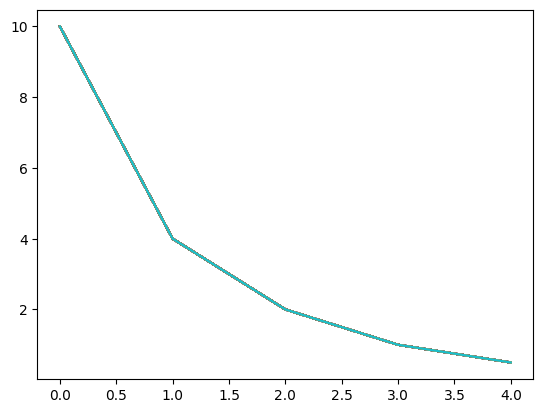

In [35]:
N_p = 100 # patients
N_t = 5 # time points (number of)
sc = 12 # scaling factor

y0 = np.zeros((N_p, N_t)) + np.array([10, 4, 2, 1, .5])

plt.plot(y0.T)
plt.show()

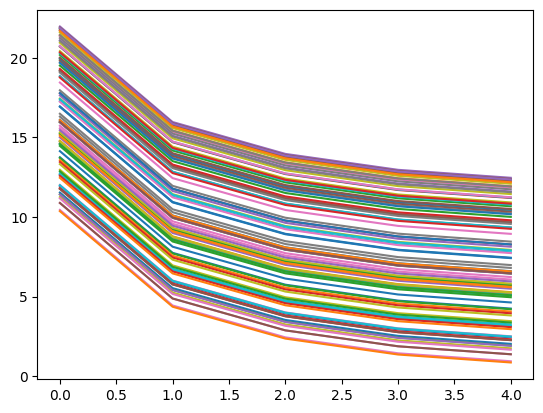

In [36]:
y_add = y0 + np.random.rand(N_p)[:, None] * sc

plt.plot(y_add.T)
plt.show()

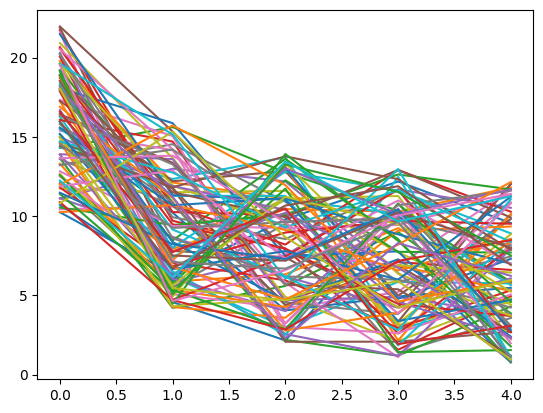

In [37]:
y_mult = y0 + np.random.rand(N_p, N_t) * sc

plt.plot(y_mult.T)
plt.show()

In [38]:
df_add = pd.DataFrame(data=y_add, columns=[f'T{i}' for i in range(N_t)])
df_add['Patient'] = np.arange(N_p) + 100
df_add = pd.melt(df_add, id_vars='Patient', value_vars=[f'T{i}' for i in range(N_t)], var_name='Week', value_name='y')

model = smf.mixedlm('y ~ Week', data=df_add, groups='Patient').fit()

model.summary()

<class 'statsmodels.iolib.summary2.Summary'>
"""
            Mixed Linear Model Regression Results
=============================================================
Model:              MixedLM   Dependent Variable:   y        
No. Observations:   500       Method:               REML     
No. Groups:         100       Scale:                0.0000   
Min. group size:    5         Log-Likelihood:       3619.0779
Max. group size:    5         Converged:            Yes      
Mean group size:    5.0                                      
-------------------------------------------------------------
            Coef.   Std.Err.      z       P>|z| [0.025 0.975]
-------------------------------------------------------------
Intercept   16.600     0.157      105.715 0.000 16.292 16.908
Week[T.T1]  -6.000     0.000 -3280765.866 0.000 -6.000 -6.000
Week[T.T2]  -8.000     0.000 -4374354.488 0.000 -8.000 -8.000
Week[T.T3]  -9.000     0.000 -4921148.798 0.000 -9.000 -9.000
Week[T.T4]  -9.500     0.000 -5194545.954 0.000 -9.500 -9.500
Patient Var  2.466 13549.830                                 
=============================================================

"""

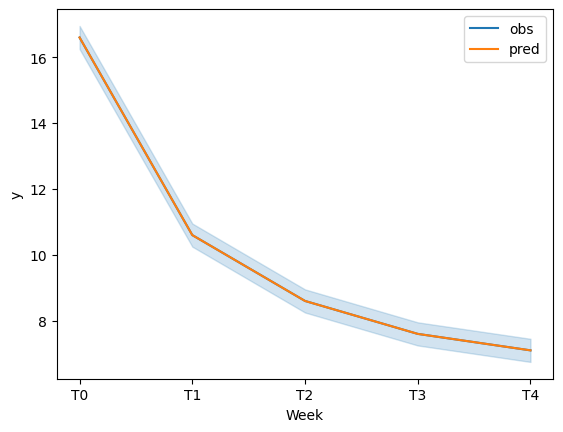

In [39]:
fe_params = model.fe_params.to_numpy()
bse = model.bse_fe.to_numpy()
b = fe_params.copy()
sem = bse.copy()
b[1:] += b[0] 
sem[1:] += sem[0]
sns.lineplot(data=df_add, x='Week', y='y', errorbar='se', label= 'obs')
plt.plot(b, label = 'pred')
plt.legend()
plt.show()
#plt.fill_between(df_add.Week.unique(), b-sem, b+sem)

In [40]:
kill = np.random.randint(low=0, high=500, size=200)
df_add_kill = df_add.drop(index=kill)

model = smf.mixedlm('y ~ Week', data=df_add_kill, groups='Patient').fit()

model.summary()


<class 'statsmodels.iolib.summary2.Summary'>
"""
            Mixed Linear Model Regression Results
=============================================================
Model:              MixedLM   Dependent Variable:   y        
No. Observations:   330       Method:               REML     
No. Groups:         99        Scale:                0.0000   
Min. group size:    1         Log-Likelihood:       1796.4848
Max. group size:    5         Converged:            Yes      
Mean group size:    3.3                                      
-------------------------------------------------------------
            Coef.   Std.Err.      z       P>|z| [0.025 0.975]
-------------------------------------------------------------
Intercept   16.652     0.193       86.461 0.000 16.274 17.029
Week[T.T1]  -6.000     0.000 -1187598.775 0.000 -6.000 -6.000
Week[T.T2]  -8.000     0.000 -1567288.541 0.000 -8.000 -8.000
Week[T.T3]  -9.000     0.000 -1793356.993 0.000 -9.000 -9.000
Week[T.T4]  -9.500     0.000 -1798975.369 0.000 -9.500 -9.500
Patient Var  3.672 12784.162                                 
=============================================================

"""

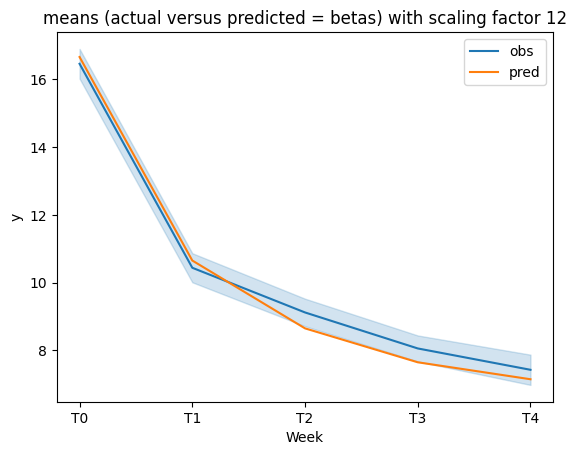

In [41]:
fe_params = model.fe_params.to_numpy()
bse = model.bse_fe.to_numpy()
b = fe_params.copy()
sem = bse.copy()

# bi + b0 = mean(timepoint i) for i != 0
b[1:] += b[0] 
sem[1:] += sem[0]

sns.lineplot(data=df_add_kill, x='Week', y='y', errorbar='se', label = 'obs')
plt.plot(b,label = 'pred')

plt.legend()
plt.title(f"means (actual versus predicted = betas) with scaling factor {sc}")
plt.show()

## Multiplicative differences

Additive differences between subjs: should make sense to use the intercept (fitted lines will be additively different by subj_intercept (re) value).

Multiplicative:

In [42]:
df_mult = pd.DataFrame(data=y_mult, columns=[f'T{i}' for i in range(N_t)])
df_mult['Patient'] = np.arange(N_p) + 100
df_mult = pd.melt(df_mult, id_vars='Patient', value_vars=[f'T{i}' for i in range(N_t)], var_name='Week', value_name='y')

model = smf.mixedlm('y ~ Week', data=df_mult, groups='Patient').fit()

model.summary()

/home/UWO/mporwal2/Documents/GitHub/smarts_cerebellum/.venv/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/home/UWO/mporwal2/Documents/GitHub/smarts_cerebellum/.venv/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


<class 'statsmodels.iolib.summary2.Summary'>
"""
         Mixed Linear Model Regression Results
========================================================
Model:            MixedLM Dependent Variable: y         
No. Observations: 500     Method:             REML      
No. Groups:       100     Scale:              11.7265   
Min. group size:  5       Log-Likelihood:     -1323.1955
Max. group size:  5       Converged:          Yes       
Mean group size:  5.0                                   
--------------------------------------------------------
            Coef.  Std.Err.    z    P>|z|  [0.025 0.975]
--------------------------------------------------------
Intercept   16.012    0.342  46.759 0.000  15.341 16.683
Week[T.T1]  -6.728    0.484 -13.892 0.000  -7.677 -5.778
Week[T.T2]  -8.038    0.484 -16.597 0.000  -8.987 -7.089
Week[T.T3]  -8.832    0.484 -18.237 0.000  -9.781 -7.883
Week[T.T4]  -9.687    0.484 -20.004 0.000 -10.637 -8.738
Patient Var  0.000    0.122                             
========================================================

"""

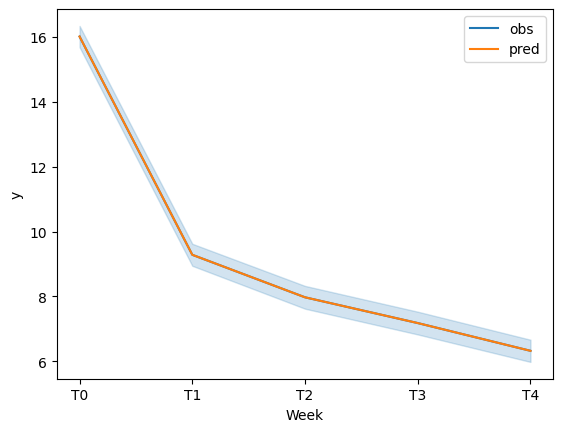

In [44]:
fe_params = model.fe_params.to_numpy()
bse = model.bse_fe.to_numpy()
b = fe_params.copy()
sem = bse.copy()
b[1:] += b[0] 
sem[1:] += sem[0]
sns.lineplot(data=df_mult, x='Week', y='y', errorbar='se', label= 'obs')
plt.plot(b, label = 'pred')
plt.legend()
plt.show()
#plt.fill_between(df_add.Week.unique(), b-sem, b+sem)

In [45]:
# same values killed as with the additive model
df_mult_kill = df_mult.drop(index=kill)

model = smf.mixedlm('y ~ Week', data=df_mult_kill, groups='Patient').fit()

model.summary()


/home/UWO/mporwal2/Documents/GitHub/smarts_cerebellum/.venv/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/UWO/mporwal2/Documents/GitHub/smarts_cerebellum/.venv/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(


<class 'statsmodels.iolib.summary2.Summary'>
"""
         Mixed Linear Model Regression Results
========================================================
Model:             MixedLM Dependent Variable: y        
No. Observations:  330     Method:             REML     
No. Groups:        99      Scale:              11.8232  
Min. group size:   1       Log-Likelihood:     -873.6719
Max. group size:   5       Converged:          Yes      
Mean group size:   3.3                                  
--------------------------------------------------------
            Coef.  Std.Err.    z    P>|z|  [0.025 0.975]
--------------------------------------------------------
Intercept   16.040    0.438  36.655 0.000  15.183 16.898
Week[T.T1]  -6.851    0.606 -11.298 0.000  -8.039 -5.662
Week[T.T2]  -7.927    0.602 -13.162 0.000  -9.107 -6.746
Week[T.T3]  -8.889    0.598 -14.857 0.000 -10.062 -7.716
Week[T.T4]  -9.689    0.625 -15.502 0.000 -10.914 -8.464
Patient Var  0.049    0.242                             
========================================================

"""

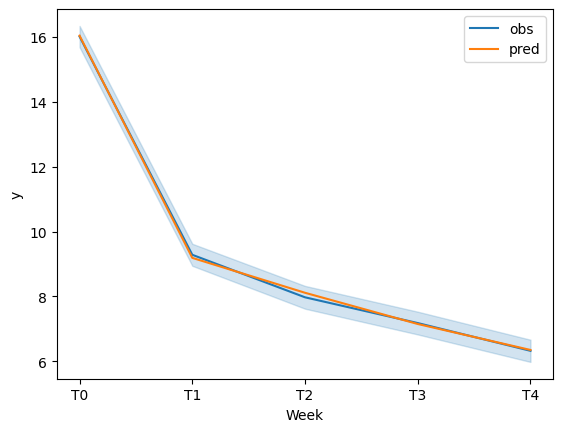

In [47]:
fe_params = model.fe_params.to_numpy()
bse = model.bse_fe.to_numpy()
b = fe_params.copy()
sem = bse.copy()
b[1:] += b[0] 
sem[1:] += sem[0]
sns.lineplot(data=df_mult, x='Week', y='y', errorbar='se', label= 'obs')
plt.plot(b, label = 'pred')
plt.legend()
plt.show()
#plt.fill_between(df_add.Week.unique(), b-sem, b+sem)